In [103]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import NullFormatter, FixedLocator, FixedFormatter

from metpy.units import units
from metpy.calc import (
    potential_temperature,
    mixing_ratio_from_specific_humidity,
)

ds = xr.open_dataset("/Users/appa/Desktop/Masters/Semester2/Experimental_Meterology/sif/data/level0/ifs.radiosondes.profiles.level0.nc")

In [ ]:
# from pathlib import Path

# date = "2026-08-09"
# cycle = "00z"
# FULL_PATH = Path.cwd().resolve().parent / "data" / "IFS" / date /"netCDF" / cycle / f"ALL-{date}-{cycle}.nc"


In [59]:
ds
# locations = ["Norderny", "Schleswig", "Fehmarn", "Greifswald"]

<xarray.Dataset> Size: 348kB
Dimensions:             (valid_time: 120, station: 4, soilLayer: 4, p: 14)
Coordinates: (12/16)
  * valid_time          (valid_time) datetime64[ns] 960B 2026-08-09T12:00:00 ...
    step                (valid_time) timedelta64[ns] 960B ...
    forecast_hour       (valid_time) <U3 1kB ...
    init_time           (valid_time) datetime64[ns] 960B ...
  * station             (station) <U10 160B 'Fehmarn' ... 'Norderney'
    latitude            (station) float64 32B ...
    ...                  ...
    surface             float64 8B ...
    heightAboveGround   float64 8B ...
    entireAtmosphere    float64 8B ...
    mostUnstableParcel  float64 8B ...
    nominalTop          float64 8B ...
    meanSea             float64 8B ...
Data variables: (12/43)
    tp                  (valid_time, station) float32 2kB ...
    sp                  (valid_time, station) float32 2kB ...
    sve                 (valid_time, station) float32 2kB ...
    mx2t3               (valid_time, station) float32 2kB ...
    tcw                 (valid_time, station) float32 2kB ...
    svn                 (valid_time, station) float32 2kB ...
    ...                  ...
    ro                  (valid_time, station) float32 2kB ...
    v                   (valid_time, station, p) float32 27kB ...
    u                   (valid_time, station, p) float32 27kB ...
    sd                  (valid_time, station) float32 2kB ...
    sf                  (valid_time, station) float32 2kB ...
    msl                 (valid_time, station) float32 2kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-18T15:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from metpy.units import units
from metpy.calc import dewpoint_from_specific_humidity
from matplotlib.ticker import NullFormatter, FixedLocator, FixedFormatter
from matplotlib.lines import Line2D


ds = xr.open_dataset("/Users/appa/Desktop/Masters/Semester2/Experimental_Meterology/sif/data/level0/ifs.radiosondes.profiles.level0.nc")

def plot_cross_section(ds, time, station_order=None):
    """
    Plot atmospheric cross section

    Parameters:
    ds : xarray.Dataset
    time : Requested valid time

    station_order : list, optional
    If None, the order stored in ds["station"] is used.
    """

    # set time (include section if time isn't exact)
    target_time = np.datetime64(time)

    valid_times = np.asarray(ds["valid_time"].values)

    # find time closest to what is requested
    time_index = np.argmin(np.abs(valid_times - target_time))

    selected_time = valid_times[time_index]

    print()
    print("TIME")
    print("-" * 70)
    print("Requested:", target_time)
    print("Selected: ", selected_time)

    # station
    dataset_stations = np.asarray(
        ds["station"].values
    ).astype(str)

    if station_order is None:
        stations = dataset_stations.copy()
    else:
        stations = np.asarray(station_order).astype(str)
        # Check station names
        missing = [
            s for s in stations
            if s not in dataset_stations
        ]

        if missing:
            raise ValueError(
                f"Stations not present in Dataset: {missing}"
            )

        if len(stations) != len(dataset_stations):
            raise ValueError(
                "station_order must contain all stations."
            )
    # set station indices
    station_indices = np.array([
        np.where(
            dataset_stations == station
        )[0][0]
        for station in stations
    ])
    
    # pressure
    pressure = np.asarray(
        ds["p"].values,
        dtype=float
    )

    # pull other variables from netCDF
    ta = ds["ta"].values[time_index, station_indices, :]
    q = ds["q"].values[time_index, station_indices, :]
    u = ds["u"].values[time_index, station_indices, :]
    v = ds["v"].values[time_index, station_indices, :]

    # change to celsius
    temperature = ta - 273.15
    dewpoint = dewpoint_from_specific_humidity(
        pressure[None, :] * units.hPa,
        ta * units.kelvin,
        q * units("kg/kg")
    )

    dewpoint = (
        dewpoint
        .to("degC")
        .magnitude
    )

    # set stations in center of cell
    nstation = len(stations)
    x_station = np.arange(nstation, dtype=float)

    # Cell boundaries
    x_min = -0.5
    x_max = nstation - 0.5
    # interpolate between stations
    x = np.linspace(x_min, x_max, 400)
    temperature_x = np.empty((len(x), len(pressure)))
    dewpoint_x = np.empty((len(x), len(pressure)))

    for j in range(len(pressure)):
        temperature_x[:, j] = np.interp(
            x,
            x_station,
            temperature[:, j]
        )

        dewpoint_x[:, j] = np.interp(
            x,
            x_station,
            dewpoint[:, j]
        )

    X, P = np.meshgrid(
        x,
        pressure,
        indexing="ij"
    )

    # plotting
    fig, ax = plt.subplots(figsize=(15, 9))
    tmin = np.floor(
        np.nanmin(temperature_x) / 5
    ) * 5

    tmax = np.ceil(
        np.nanmax(temperature_x) / 5
    ) * 5

    temperature_levels = np.arange(
        tmin,
        tmax + 5,
        5
    )

    # background contour settings
    cf = ax.contourf(
        X,
        P,
        temperature_x,
        levels=temperature_levels,
        cmap="RdBu_r",
        extend="both"
    )
    # temperature contours
    temp_cs = ax.contour(
        X,
        P,
        temperature_x,
        levels=temperature_levels,
        colors="black",
        linewidths=0.8
    )

    ax.clabel(
        temp_cs,
        inline=True,
        fontsize=8,
        fmt="%d°C"
    )
    # dewpoint contours
    tdmin = np.floor(
        np.nanmin(dewpoint_x) / 5
    ) * 5

    tdmax = np.ceil(
        np.nanmax(dewpoint_x) / 5
    ) * 5

    dewpoint_levels = np.arange(
        tdmin,
        tdmax + 5,
        5
    )

    td_cs = ax.contour(
        X,
        P,
        dewpoint_x,
        levels=dewpoint_levels,
        colors="limegreen",

        linewidths=1.5
    )

    ax.clabel(
        td_cs,
        inline=True,
        fontsize=8,
        fmt="%d°C"
    )
    # wind bars
    requested_pressure = np.array([
        1000,
        925,
        850,
        700,
        500,
        300,
        200
    ])

    # Only plot levels that exist in the Dataset
    valid_pressure = requested_pressure[
        np.isin(
            requested_pressure,
            pressure
        )
    ]

    # Find indices directly
    barb_indices = np.array([
        np.where(
            pressure == level
        )[0][0]
        for level in valid_pressure
    ])

    # Barbs stay at actual station locations
    barb_x = np.repeat(
        x_station[:, None],
        len(barb_indices),
        axis=1
    )

    barb_y = np.tile(
        pressure[barb_indices],
        (nstation, 1)
    )

    barb_u = u[
        :,
        barb_indices
    ]

    barb_v = v[
        :,
        barb_indices
    ]

    ax.barbs(
        barb_x,
        barb_y,
        barb_u,
        barb_v,
        length=6,
        linewidth=1.0,
        color="black"
    )

    # Setting pressure acis (y-axis)
    ax.set_yscale("log")
    ax.set_ylim(1000, 200)

    pressure_ticks = [
        1000,
        925,
        850,
        700,
        500,
        300,
        200
    ]

    ax.yaxis.set_major_locator(
        FixedLocator(pressure_ticks)
    )

    ax.yaxis.set_major_formatter(
        FixedFormatter([
            "1000",
            "925",
            "850",
            "700",
            "500",
            "300",
            "200"
        ])
    )
    # don't allow scientifc notation
    ax.yaxis.set_minor_formatter(NullFormatter())
    

    # x-axis 
    ax.set_xlim(
        x_min,
        x_max
    )

    ax.set_xticks(
        x_station
    )

    ax.set_xticklabels(
        stations,
        rotation=45,
        ha="right"
    )

    # station locations
    for xpos in x_station:

        ax.axvline(
            xpos,
            color="gray",
            linewidth=0.6,
            linestyle=":",
            alpha=0.4
        )

    ax.set_xlabel("Station")

    ax.set_ylabel("Pressure (hPa)")

    ax.set_title(
        "Atmospheric Cross Section\n"
        f"Valid: {selected_time}"
    )

    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label("Temperature (°C)")
    ax.grid(True, which="major", linestyle="--",alpha=0.25) 

    legend_lines = [
        Line2D(
            [0], [0],
            color="black",
            linewidth=1.0,
            label="Temperature (°C)"
        ),
        Line2D(
            [0], [0],
            color="limegreen",
            linewidth=1.5,
            label="Dewpoint (°C)"
        )
    ]

    ax.legend(
        handles=legend_lines,
        loc="upper right"
    )
    
    plt.tight_layout()
    plt.show()



TIME
----------------------------------------------------------------------
Requested: 2026-08-09T12:00:00.000000000
Selected:  2026-08-09T12:00:00.000000000


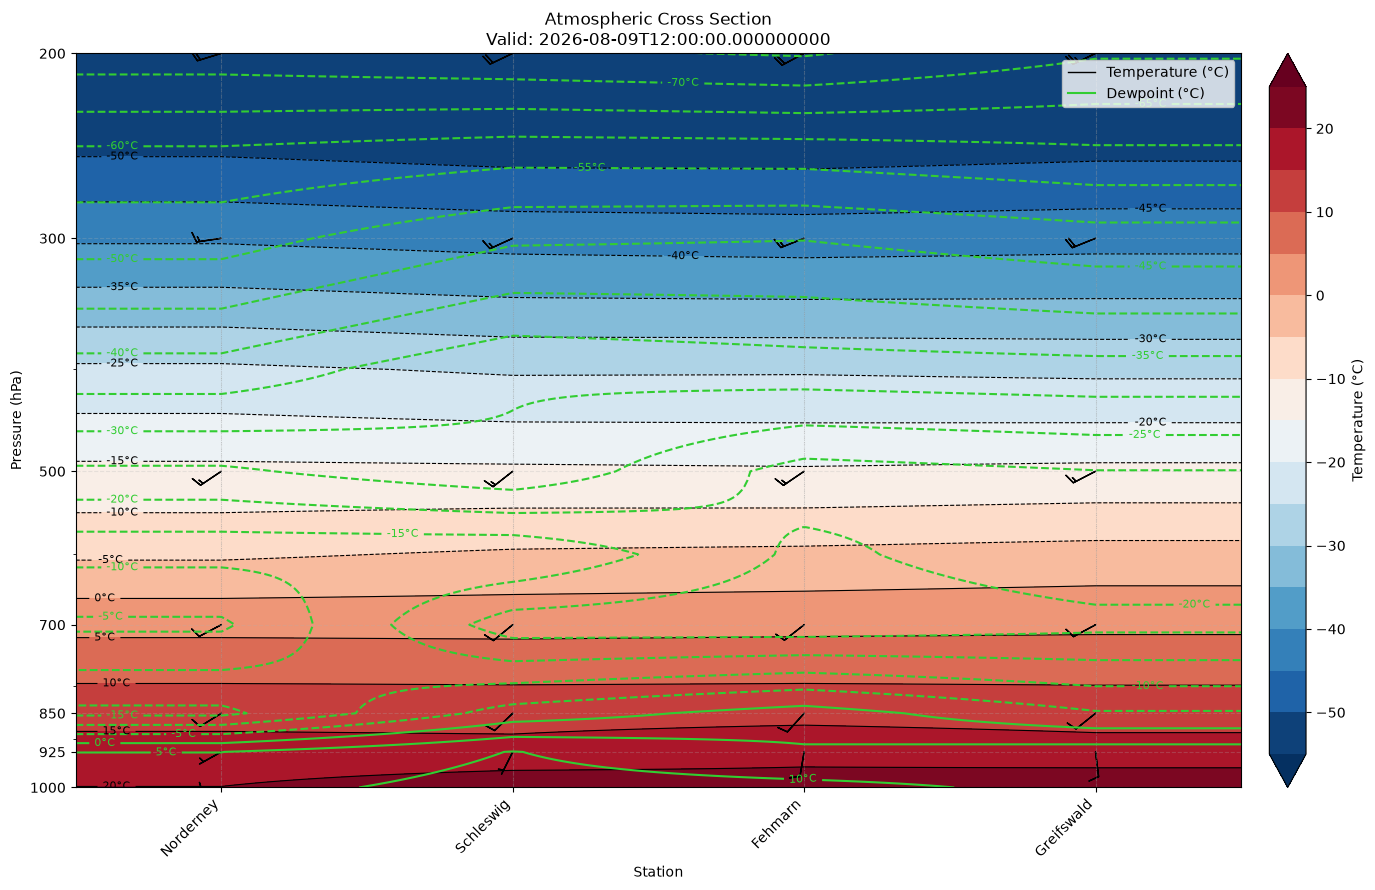

In [14]:
time = "2026-08-09T12:00:00.000000000"

plot_cross_section(ds, time, 
        station_order=["Norderney","Schleswig", "Fehmarn", "Greifswald"])